In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.train import net_train_AnyNet_L, net_train_ViT_L, net_train_RNN_L, net_train_LC_L
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code
Library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [4]:
spectrogram_acronym = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/spectrogram_acronym.pt', weights_only=False)

In [10]:
spectrogram_acronym.keys()

dict_keys(['FRP1', 'FRP2/3', 'FRP5', 'FRP6a', 'MOp1', 'MOp2/3', 'MOp5', 'MOp6a', 'MOp6b', 'MOs1', 'MOs2/3', 'MOs5', 'MOs6a', 'MOs6b', 'SSp-n1', 'SSp-n2/3', 'SSp-n4', 'SSp-n5', 'SSp-n6a', 'SSp-n6b', 'SSp-bfd1', 'SSp-bfd2/3', 'SSp-bfd4', 'SSp-bfd5', 'SSp-bfd6a', 'SSp-bfd6b', 'SSp-ll1', 'SSp-ll2/3', 'SSp-ll4', 'SSp-ll5', 'SSp-ll6a', 'SSp-ll6b', 'SSp-m2/3', 'SSp-m4', 'SSp-m5', 'SSp-m6a', 'SSp-m6b', 'SSp-ul1', 'SSp-ul2/3', 'SSp-ul4', 'SSp-ul5', 'SSp-ul6a', 'SSp-ul6b', 'SSp-tr1', 'SSp-tr2/3', 'SSp-tr4', 'SSp-tr5', 'SSp-tr6a', 'SSp-tr6b', 'SSp-un1', 'SSp-un2/3', 'SSp-un4', 'SSp-un5', 'SSp-un6a', 'SSp-un6b', 'SSs2/3', 'SSs4', 'SSs5', 'SSs6a', 'SSs6b', 'GU5', 'GU6a', 'VISC5', 'VISC6a', 'VISC6b', 'AUDd5', 'AUDd6a', 'AUDp6a', 'AUDpo5', 'AUDpo6a', 'AUDpo6b', 'AUDv6a', 'AUDv6b', 'VISal2/3', 'VISal4', 'VISal6a', 'VISal6b', 'VISam1', 'VISam2/3', 'VISam4', 'VISam5', 'VISam6a', 'VISam6b', 'VISl1', 'VISl2/3', 'VISl4', 'VISl5', 'VISl6a', 'VISl6b', 'VISp1', 'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b',

In [ ]:
# Classifier_name = ['AnyNet', 'ViT', 'RNN']
# spectrogram_hist = {}
# for classifier in Classifier_name:
#     hist_2d = []
#     for acronym in acronym_list:
#         try:
#             for coord in np.argwhere(spectrogram_acronym[acronym]['dl'][classifier] == np.max(spectrogram_acronym[acronym]['dl'][classifier])):
#                 hist_2d.append(coord)

#         except:
#             continue

#     spectrogram_hist[classifier] = np.array(hist_2d)


In [ ]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
spectrogram_hist_positive = {}
spectrogram_hist_negative = {}
for classifier in Classifier_name:
    hist_2d = []
    for acronym in acronym_list:
        try:
            spectrogram = np.zeros((224, 28))
            spectrogram[spectrogram_acronym[acronym]['dl'][classifier] > 0] = 1
            hist_2d.append(spectrogram)

        except:
            continue

    spectrogram_hist_positive[classifier] = np.array(hist_2d)

spectrogram_hist_raw = {}
hist_2d = []
for acronym in acronym_list:
    try:
        spectrogram = spectrogram_acronym[acronym]['raw']
        hist_2d.append(spectrogram)

    except:
        continue

spectrogram_hist_raw['raw'] = np.array(hist_2d)

# for classifier in Classifier_name:
#     hist_2d = []
#     for acronym in acronym_list:
#         try:
#             spectrogram = np.zeros((224, 28))
#             spectrogram[spectrogram_acronym[acronym]['dl'][classifier] < 0] = 1
#             hist_2d.append(spectrogram)

#         except:
#             continue

#     spectrogram_hist_negative[classifier] = np.array(hist_2d)


In [ ]:
# classifier = 'AnyNet'
# plt.figure(figsize=(2, 5), dpi=200)
# plt.subplot(1, 2, 1)
# plt.imshow(spectrogram_hist_positive[classifier].mean(axis=0), cmap='Reds')
# plt.subplot(1, 2, 2)
# plt.imshow(spectrogram_hist_negative[classifier].mean(axis=0), cmap='Blues')
# sns.despine()
# plt.show()

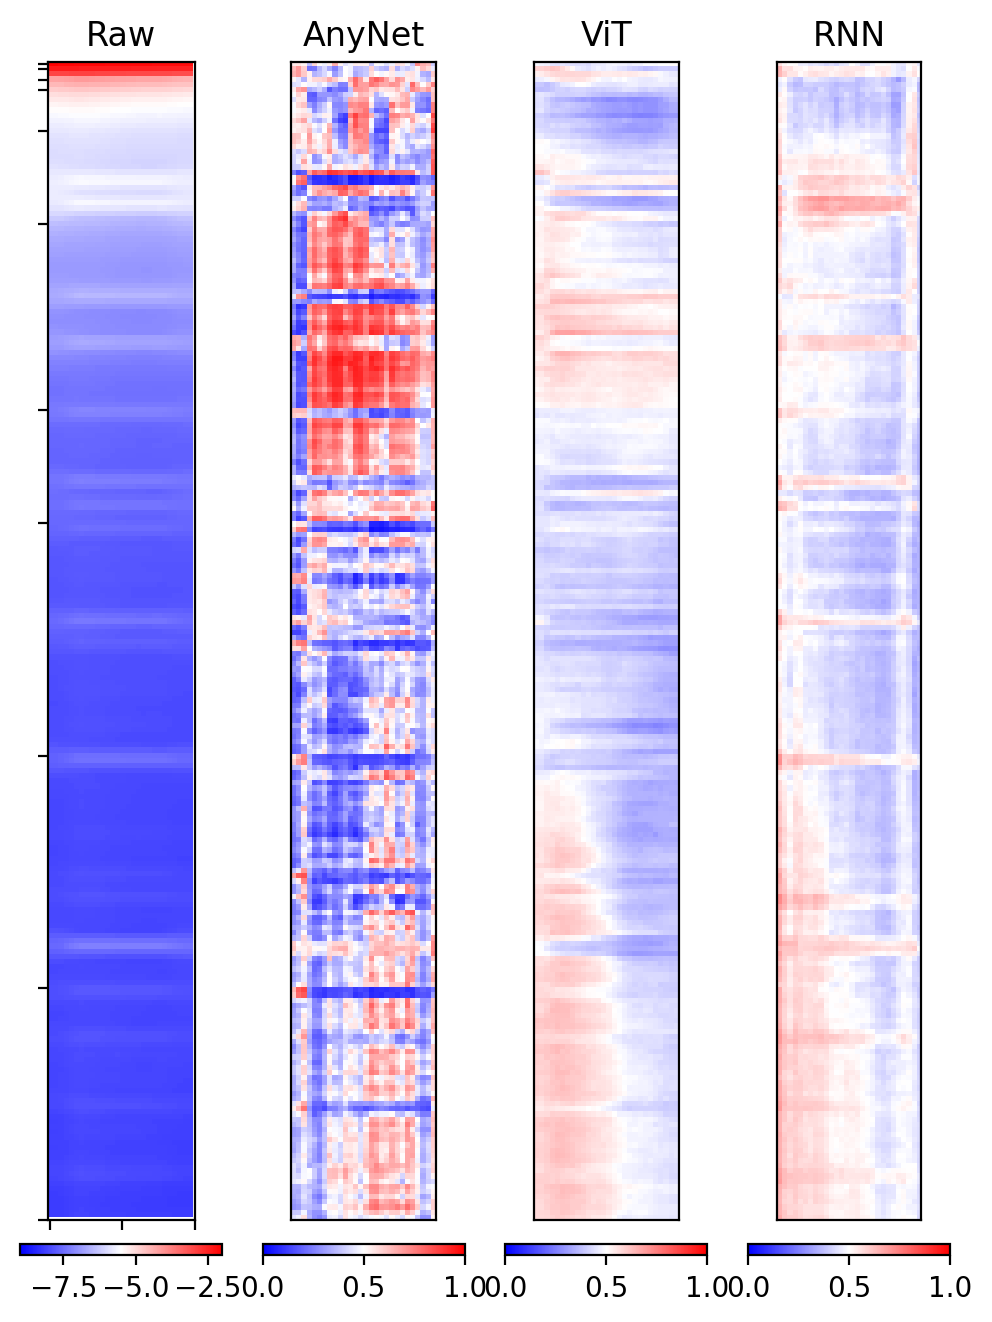

In [ ]:
delta_show = 1e-9
orient = 'horizontal'
plt.figure(figsize=(6, 8), dpi=200)
plt.subplot(1, 4, 1)
plt.imshow(np.log(spectrogram_hist_raw['raw'].mean(axis=0) + delta_show), vmin=-9.0, vmax=-2, cmap='bwr')
# plt.axis('off')
plt.yticks(np.int32(np.array([1, 4, 8, 12, 30, 70, 150, 200, 300, 400, 500]) / (500 / 224)), ['', '', '', '', '', '', '', '', '', '', ''])
plt.xticks(np.linspace(0, 28, 3), ['', '', ''])
plt.title('Raw')
plt.colorbar(orientation=orient, pad=0.02, shrink=1.0, fraction=0.04)
for classifier_ii, classifier in enumerate(Classifier_name):
    plt.subplot(1, 4, classifier_ii + 2)
    plt.imshow(spectrogram_hist_positive[classifier].mean(axis=0), vmin=0.0, vmax=1.0, cmap='bwr')
    plt.colorbar(orientation=orient, pad=0.02, shrink=1.0, fraction=0.04)
    plt.yticks([])
    plt.xticks([])
    plt.title(classifier)
# sns.despine()
plt.show()

# plt.figure(figsize=(5, 6), dpi=200)
# for classifier_ii, classifier in enumerate(Classifier_name):
#     plt.subplot(1, 3, classifier_ii + 1)
#     plt.imshow(spectrogram_hist_negative[classifier].mean(axis=0), cmap='Blues')
# sns.despine()
# plt.show()
